##### imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
import math
import calendar


## Data loading

In [2]:
# Define paths to the storm events CSV files
data_dir = Path('../datasets\\')
files = [
    data_dir / 'StormEvents_details-ftp_v1.0_d2016_c20250818.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2017_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2018_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2019_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2020_c20251118.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2021_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2022_c20250721.csv',
]

# Load datasets
print("Loading datasets...")
df_list = []
for file in files:
    # print(f"  Loading {file.name}...")
    df = pd.read_csv(file)
    # print(f"    Shape: {df.shape}")
    df_list.append(df)

# Concatenate the datasets
df = pd.concat(df_list, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")

Loading datasets...

Combined dataset shape: (436146, 51)


In [3]:
df.columns

Index(['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH',
       'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
       'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
       'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE',
       'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE',
       'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE',
       'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
       'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
       'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE'],
      dtype='object')

In [4]:
df.head()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,201607,15,1715,201607,15,1715,108769,651823,SOUTH CAROLINA,45,...,1.0,N,BOYD HILL,34.94,-81.03,34.94,-81.03,Scattered thunderstorms developed across the U...,One to two feet of deep standing water develop...,CSV
1,201607,15,1725,201607,15,1725,108769,651825,SOUTH CAROLINA,45,...,1.0,S,FT MILL,35.01,-80.93,35.01,-80.93,Scattered thunderstorms developed across the U...,NWS Columbia relayed a report of trees blown d...,CSV
2,201607,16,1246,201607,16,1246,108812,651828,NORTH CAROLINA,37,...,2.0,ENE,OLD FT,35.64,-82.14,35.64,-82.14,Scattered thunderstorms developed near the Blu...,Media reported two trees blown down along I-40...,CSV
3,201607,8,1755,201607,8,1755,105872,635287,TENNESSEE,47,...,1.0,W,JENA,35.65,-84.18,35.65,-84.18,The combination of summer heating and high low...,Numerous trees were reported down in the Green...,CSV
4,201607,8,1810,201607,8,1810,105872,635296,TENNESSEE,47,...,1.0,WSW,PITNER,35.87,-83.77,35.87,-83.77,The combination of summer heating and high low...,Numerous trees were reported down in Seymour. ...,CSV


## Inspect dataset

### Remove useless cols

In [5]:
useless_cols = [
    'BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 
    'END_YEARMONTH', 'END_DAY', 'END_TIME',
    'EPISODE_ID', 'EVENT_ID',
    'STATE_FIPS',
    'SOURCE',
    'YEAR',
    'MONTH_NAME',
    'WFO',
    'CATEGORY',
    'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 
    'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME', 'CZ_TIMEZONE',
    'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE'
]

df = df.drop(columns=useless_cols, inplace=False)

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
STATE,436146,67,TEXAS,29023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EVENT_TYPE,436146,53,Thunderstorm Wind,117814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BEGIN_DATE_TIME,436146,235058,01-NOV-22 00:00:00,687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
END_DATE_TIME,436146,228718,31-OCT-22 23:59:00,641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INJURIES_DIRECT,436146.0,NaN,NaN,NaN,0.021626,1.092454,0.0,0.0,0.0,0.0,350.0
INJURIES_INDIRECT,436146.0,NaN,NaN,NaN,0.007055,0.836619,0.0,0.0,0.0,0.0,500.0
DEATHS_DIRECT,436146.0,NaN,NaN,NaN,0.011088,0.327882,0.0,0.0,0.0,0.0,93.0
DEATHS_INDIRECT,436146.0,NaN,NaN,NaN,0.003939,0.109078,0.0,0.0,0.0,0.0,21.0
DAMAGE_PROPERTY,346532,1077,0.00K,260163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DAMAGE_CROPS,348546,568,0.00K,343303,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Encode categorical cols

In [7]:
# damages map functions to numeric values
def damage_to_numeric(damage_str):
    if pd.isna(damage_str):
        return 0
    multipliers = {'K': 1_000, 'M': 1_000_000, 'B': 1_000_000_000}
    if damage_str[-1] in multipliers:
        try:
            value = float(damage_str[:-1])
            return value * multipliers[damage_str[-1]]
        except ValueError:
            return 0
    try:
        return float(damage_str)
    except ValueError:
        return 0    

In [8]:
df_numeric = df.select_dtypes(include=[np.number])


df_numeric['STATE'] = df['STATE'].astype('category').cat.codes
df_numeric['EVENT_TYPE'] = df['EVENT_TYPE'].astype('category').cat.codes

df_numeric['DAMAGE_PROPERTY'] = df['DAMAGE_PROPERTY'].apply(damage_to_numeric)
df_numeric['DAMAGE_CROPS'] = df['DAMAGE_CROPS'].apply(damage_to_numeric)
df_numeric['MAGNITUDE_TYPE'] = df['MAGNITUDE_TYPE'].astype('category').cat.codes+1
df_numeric['FLOOD_CAUSE'] = df['FLOOD_CAUSE'].astype('category').cat.codes+1
df_numeric['TOR_F_SCALE'] = df['TOR_F_SCALE'].astype('category').cat.codes+1

# encode azimuthal direction columns as angles in degrees
df_numeric['BEGIN_AZIMUTH'] = df['BEGIN_AZIMUTH'].astype('category').cat.codes * (360 / (df['BEGIN_AZIMUTH'].nunique()-1))
df_numeric.loc[df_numeric['BEGIN_AZIMUTH'] ==  -24.0] = np.nan
df_numeric['END_AZIMUTH'] = df['END_AZIMUTH'].astype('category').cat.codes * (360 / (df['END_AZIMUTH'].nunique()-1))
df_numeric.loc[df_numeric['END_AZIMUTH'] ==  -24.0] = np.nan

df_numeric['BEGIN_LOCATION'] = df['BEGIN_LOCATION'].astype('category').cat.codes+1
df_numeric['END_LOCATION'] = df['END_LOCATION'].astype('category').cat.codes+1

In [9]:
df_numeric.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
INJURIES_DIRECT,268165.0,0.020875,9.867923e-01,0.0000,0.00,0.0000,0.0000,2.100000e+02
INJURIES_INDIRECT,268165.0,0.001428,2.063676e-01,0.0000,0.00,0.0000,0.0000,1.000000e+02
DEATHS_DIRECT,268165.0,0.005519,1.712446e-01,0.0000,0.00,0.0000,0.0000,3.600000e+01
DEATHS_INDIRECT,268165.0,0.000567,2.824355e-02,0.0000,0.00,0.0000,0.0000,4.000000e+00
MAGNITUDE,193322.0,36.698390,2.411629e+01,0.1300,1.75,50.0000,52.0000,1.260000e+02
TOR_LENGTH,9890.0,3.104619,4.026819e+00,0.0100,0.50,1.6600,4.1100,4.188000e+01
TOR_WIDTH,9890.0,196.033716,2.971936e+02,1.0000,50.00,100.0000,200.0000,3.960000e+03
BEGIN_RANGE,268165.0,2.423877,4.516419e+00,0.0000,1.00,1.0000,3.0000,1.850000e+02
END_RANGE,268165.0,2.444987,4.531018e+00,0.0000,1.00,1.0000,3.0000,1.850000e+02
BEGIN_LAT,268165.0,37.813228,5.195132e+00,-14.3629,34.57,38.3100,41.3600,6.683850e+01


### Plot correlations

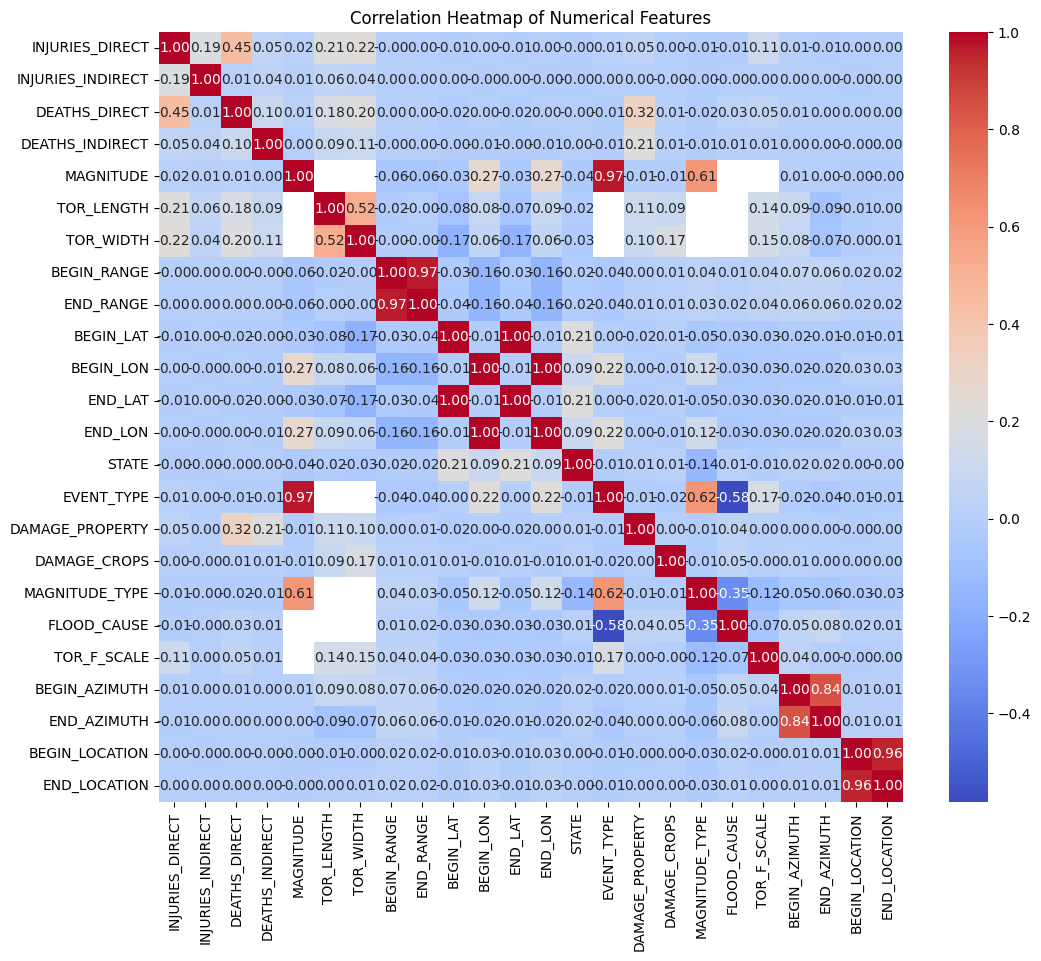

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

#### 

### Remove irrelevant cols

In [11]:
irrelevant_cols = [
    'FLOOD_CAUSE',
    'TOR_LENGTH',
    'TOR_WIDTH',
    'BEGIN_RANGE',
    'BEGIN_AZIMUTH',
    'BEGIN_LOCATION',
    'END_RANGE',
    'END_AZIMUTH',
    'END_LOCATION',
    'END_LAT',
    'END_LON',
]

df.drop(columns=irrelevant_cols, inplace=True)
df_numeric.drop(columns=irrelevant_cols, inplace=True)

In [12]:
df.head()

,STATE,EVENT_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,MAGNITUDE,MAGNITUDE_TYPE,TOR_F_SCALE,BEGIN_LAT,BEGIN_LON
0,SOUTH CAROLINA,Heavy Rain,15-JUL-16 17:15:00,15-JUL-16 17:15:00,0,0,0,0,2.00K,0.00K,NaN,NaN,NaN,34.94,-81.03
1,SOUTH CAROLINA,Thunderstorm Wind,15-JUL-16 17:25:00,15-JUL-16 17:25:00,0,0,0,0,0.00K,0.00K,50.0,EG,NaN,35.01,-80.93
2,NORTH CAROLINA,Thunderstorm Wind,16-JUL-16 12:46:00,16-JUL-16 12:46:00,0,0,0,0,0.00K,0.00K,50.0,EG,NaN,35.64,-82.14
3,TENNESSEE,Thunderstorm Wind,08-JUL-16 17:55:00,08-JUL-16 17:55:00,0,0,0,0,NaN,NaN,50.0,EG,NaN,35.65,-84.18
4,TENNESSEE,Thunderstorm Wind,08-JUL-16 18:10:00,08-JUL-16 18:10:00,0,0,0,0,NaN,NaN,60.0,EG,NaN,35.87,-83.77


## Inspect single cols

### Event Type   

#### Remove unpredictable events

In [13]:
[df['EVENT_TYPE'].value_counts().index]

[Index(['Thunderstorm Wind', 'Hail', 'Flash Flood', 'High Wind',
        'Winter Weather', 'Flood', 'Winter Storm', 'Drought',
        'Marine Thunderstorm Wind', 'Heavy Snow', 'Heavy Rain', 'Tornado',
        'Heat', 'Strong Wind', 'Excessive Heat', 'Extreme Cold/Wind Chill',
        'Dense Fog', 'Frost/Freeze', 'Blizzard', 'Cold/Wind Chill', 'High Surf',
        'Wildfire', 'Tropical Storm', 'Lightning', 'Funnel Cloud', 'Ice Storm',
        'Coastal Flood', 'Waterspout', 'Debris Flow', 'Lake-Effect Snow',
        'Dust Storm', 'Rip Current', 'Marine High Wind',
        'Marine Tropical Storm', 'Storm Surge/Tide', 'Lakeshore Flood',
        'Hurricane (Typhoon)', 'Avalanche', 'Marine Hail',
        'Astronomical Low Tide', 'Tropical Depression', 'Sleet',
        'Marine Hurricane/Typhoon', 'Dense Smoke', 'Volcanic Ashfall',
        'Marine Strong Wind', 'Freezing Fog', 'Dust Devil',
        'Marine Tropical Depression', 'Seiche', 'Marine Dense Fog',
        'Sneakerwave', 'Tsunami'],


In [14]:
unpredictable_events = ['High Surf', 'Sneakerwave', 'Seiche', 'Dense Smoke', 'Rip Current', 'Tropical Depression', 'Tsunami',
                    'Marine Tropical Depression', 'Volcanic Ashfall', 'Astronomical Low Tide', 'Dust Devil', 'Storm Surge/Tide']

# remove unheard of events from dataset
df = df[~df['EVENT_TYPE'].isin(unpredictable_events)]
df_numeric = df_numeric.loc[df.index]

[df['EVENT_TYPE'].value_counts().index]

[Index(['Thunderstorm Wind', 'Hail', 'Flash Flood', 'High Wind',
        'Winter Weather', 'Flood', 'Winter Storm', 'Drought',
        'Marine Thunderstorm Wind', 'Heavy Snow', 'Heavy Rain', 'Tornado',
        'Heat', 'Strong Wind', 'Excessive Heat', 'Extreme Cold/Wind Chill',
        'Dense Fog', 'Frost/Freeze', 'Blizzard', 'Cold/Wind Chill', 'Wildfire',
        'Tropical Storm', 'Lightning', 'Funnel Cloud', 'Ice Storm',
        'Coastal Flood', 'Waterspout', 'Debris Flow', 'Lake-Effect Snow',
        'Dust Storm', 'Marine High Wind', 'Marine Tropical Storm',
        'Lakeshore Flood', 'Hurricane (Typhoon)', 'Avalanche', 'Marine Hail',
        'Sleet', 'Marine Hurricane/Typhoon', 'Marine Strong Wind',
        'Freezing Fog', 'Marine Dense Fog'],
       dtype='object', name='EVENT_TYPE')]

#### Plots

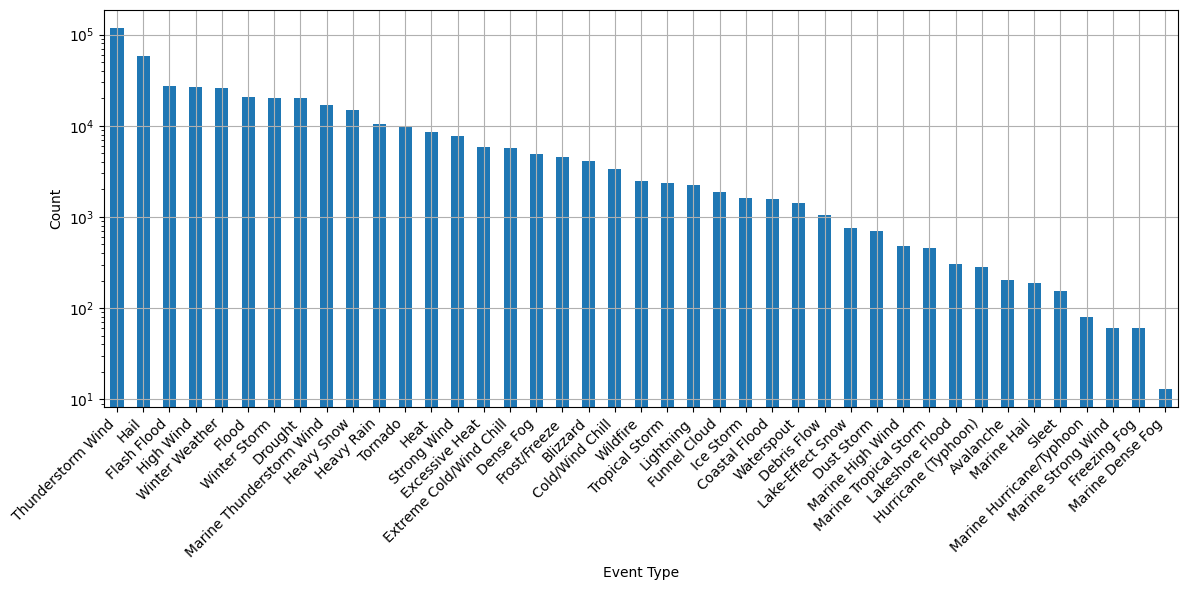

In [15]:
df['EVENT_TYPE'].value_counts().plot(kind='bar', figsize=(12, 6))
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.tight_layout()
plt.grid()
plt.show()

C:\Users\matti\AppData\Local\Temp\ipykernel_16556\133792523.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['BEGIN_DATE_TIME'] = pd.to_datetime(df.get('BEGIN_DATE_TIME', None), errors='coerce')


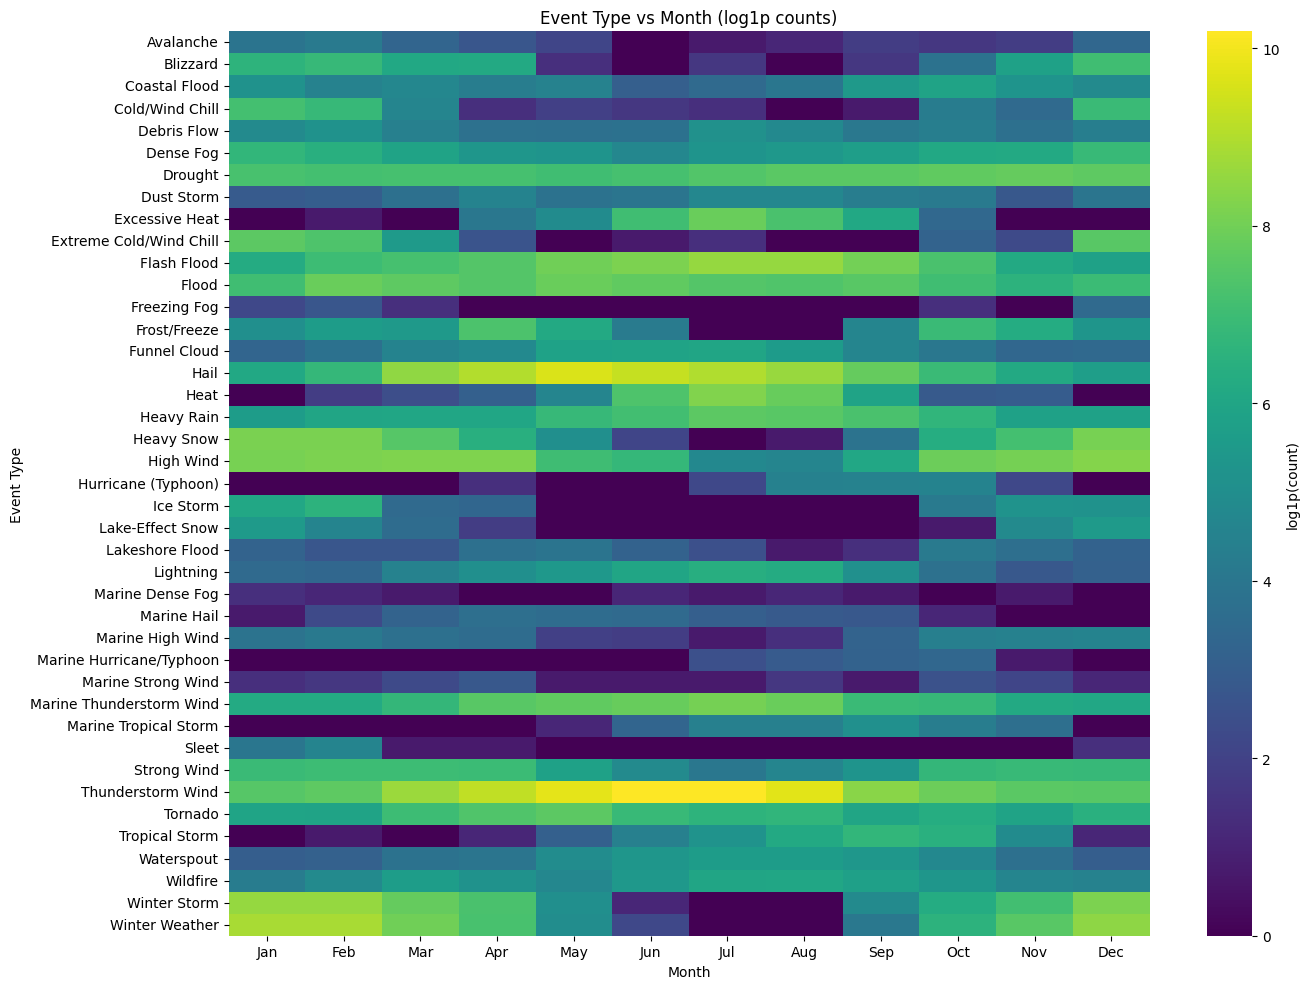

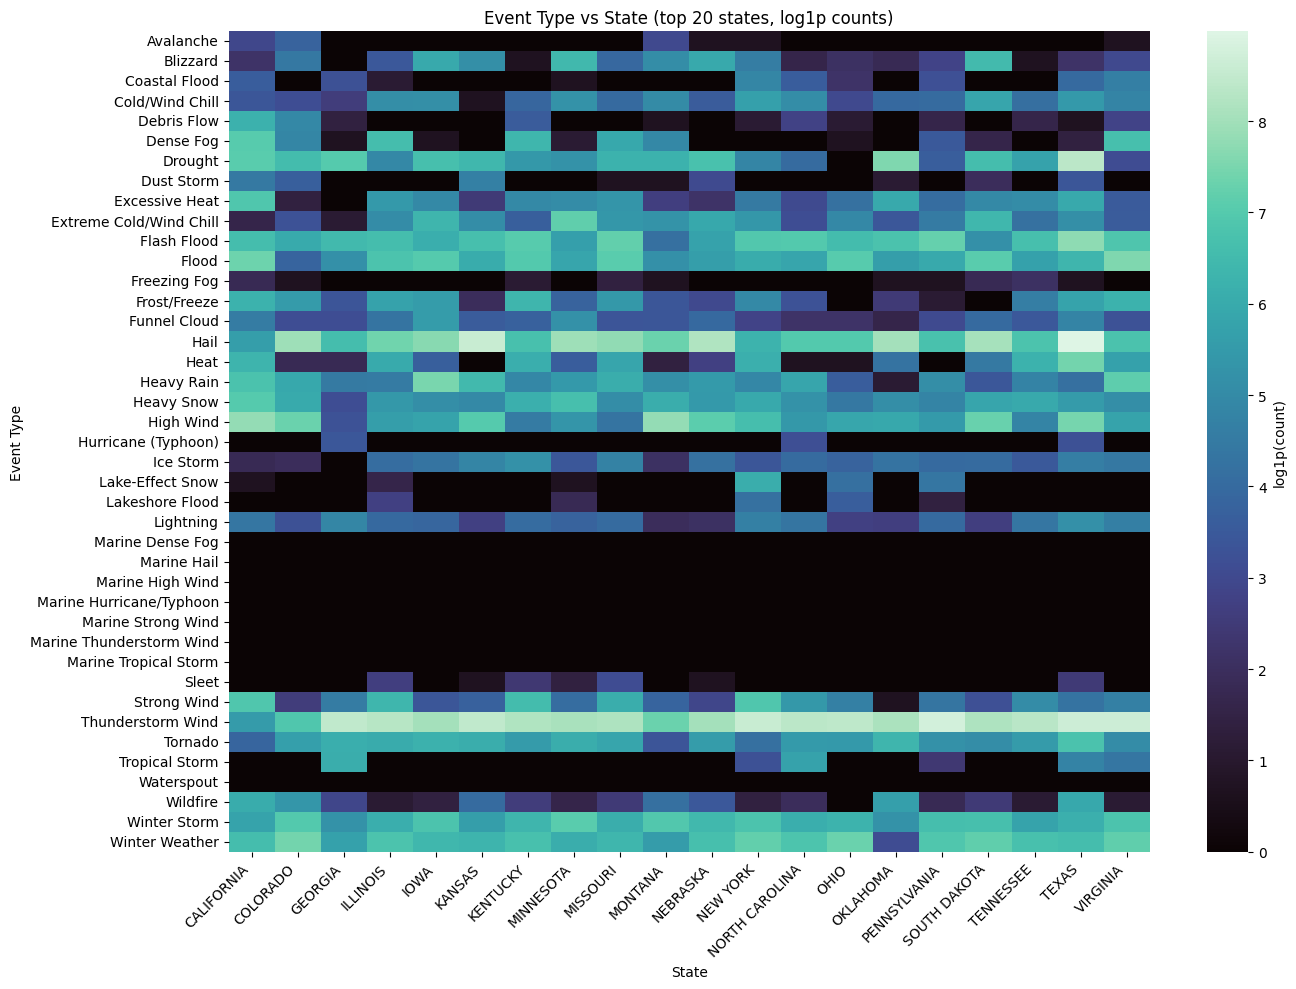

C:\Users\matti\AppData\Local\Temp\ipykernel_16556\133792523.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=damage_by_event.values, y=damage_by_event.index, palette='rocket')


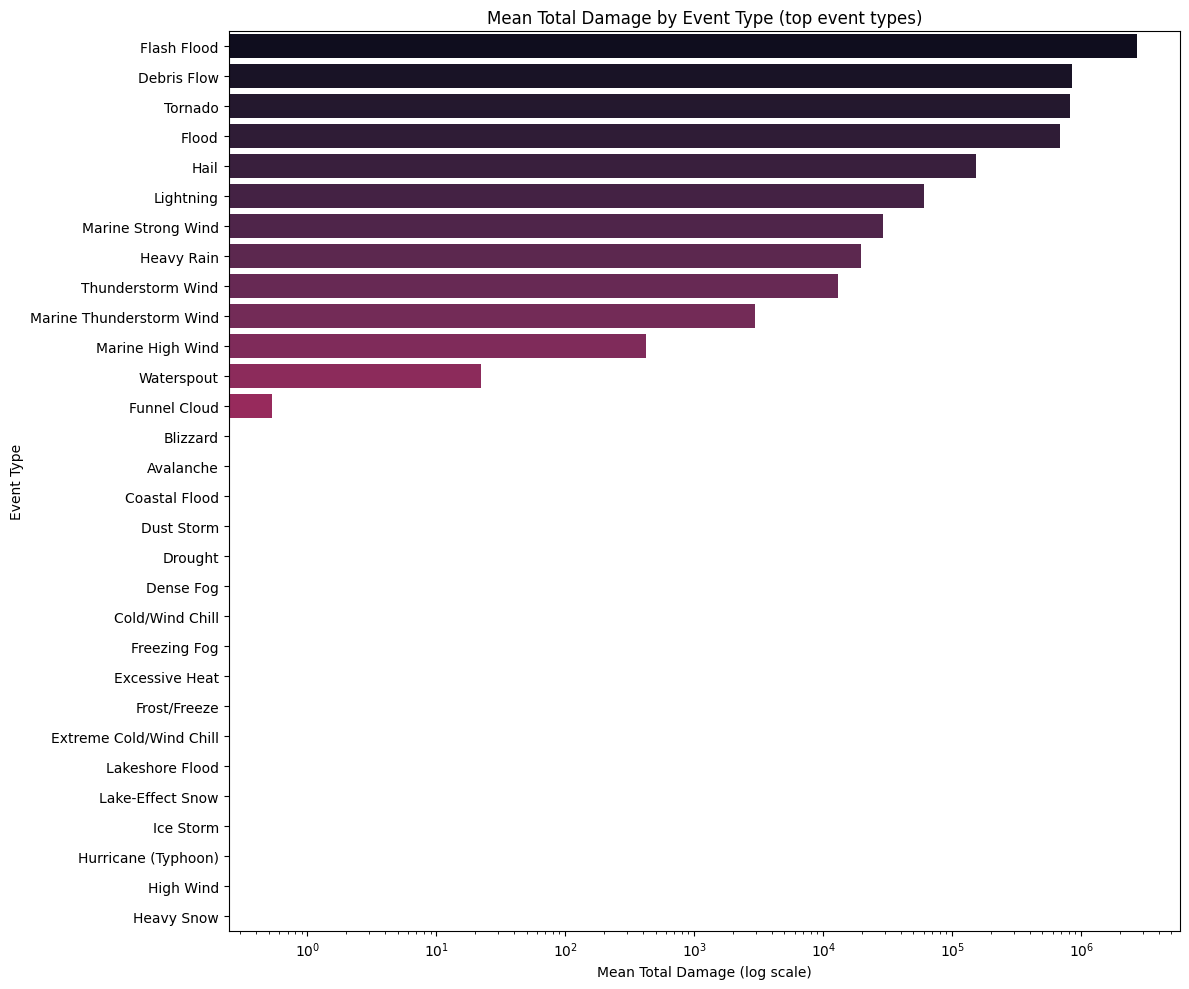

In [16]:
# Plot correlations: event type vs month, location (state), and damages

# ensure datetime and month
df['BEGIN_DATE_TIME'] = pd.to_datetime(df.get('BEGIN_DATE_TIME', None), errors='coerce')
df['month_num'] = df['BEGIN_DATE_TIME'].dt.month
df['month_name'] = df['month_num'].apply(lambda m: calendar.month_abbr[m] if not pd.isna(m) else None)

# 1) Heatmap: Event Type vs Month (counts, log-scaled)
pivot_month = pd.crosstab(df['EVENT_TYPE'], df['month_num']).reindex(columns=range(1,13), fill_value=0)
plt.figure(figsize=(14,10))
sns.heatmap(np.log1p(pivot_month), cmap='viridis', cbar_kws={'label':'log1p(count)'})
plt.title('Event Type vs Month (log1p counts)')
plt.xlabel('Month')
plt.ylabel('Event Type')
plt.xticks(np.arange(12)+0.5, [calendar.month_abbr[m] for m in range(1,13)], rotation=0)
plt.tight_layout()
plt.show()

# 2) Heatmap: Event Type vs State (top 20 states by event count)
top_states = df['STATE'].value_counts().nlargest(20).index
pivot_state = pd.crosstab(df['EVENT_TYPE'], df['STATE'])
pivot_state = pivot_state.loc[:, pivot_state.columns.isin(top_states)]
plt.figure(figsize=(14,10))
sns.heatmap(np.log1p(pivot_state), cmap='mako', cbar_kws={'label':'log1p(count)'})
plt.title('Event Type vs State (top 20 states, log1p counts)')
plt.xlabel('State')
plt.ylabel('Event Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3) Damage distribution by Event Type (use numeric damage columns)
df_numeric['DAMAGE_PROPERTY'] = df_numeric.get('DAMAGE_PROPERTY', 0).fillna(0)
df_numeric['DAMAGE_CROPS'] = df_numeric.get('DAMAGE_CROPS', 0).fillna(0)
df['damage_total'] = (df_numeric['DAMAGE_PROPERTY'] + df_numeric['DAMAGE_CROPS']).fillna(0)

# focus on event types with enough samples
counts = df['EVENT_TYPE'].value_counts()
top_events = counts[counts >= 50].index  # adjust threshold if needed
damage_by_event = df.loc[df['EVENT_TYPE'].isin(top_events)].groupby('EVENT_TYPE')['damage_total'].mean().sort_values(ascending=False).head(30)

plt.figure(figsize=(12,10))
sns.barplot(x=damage_by_event.values, y=damage_by_event.index, palette='rocket')
plt.xscale('log')  # damages are skewed
plt.xlabel('Mean Total Damage (log scale)')
plt.ylabel('Event Type')
plt.title('Mean Total Damage by Event Type (top event types)')
plt.tight_layout()
plt.show()

#### Aggregation

We can use the plots above to aggregate similar events into:  
- Hail: Hail, Marine Hail
- Flood: Flood, Flash Flood, Coastal Flood, Lakeshore Flood
- Freeze: Winter Weather, Extreme Cold/Wind Chill, Frost/Freeze, Cold/Wind Chill, Freezing Fog
- Heat: Heat, Excessive Heat, 
- Snow: Heavy Snow, Blizzard, Lake-Effect Snow, Sleet
- Storm: Winter Storm, Marine Thunderstorm Wind, Tornado, Tropical Storm, Funnel Cloud, Dust Storm
    Ice Storm, Waterspout, Marine Tropical Storm, Hurricane (Typhoon), Marine Hurricane/Typhoon
- Wind: High Wind, Strong Wind, Marine High WindMarine Strong Wind
- Fog: Dense Fog, Marine Dense Fog
  
Heavy Rain, Drought, Wildfire, Lightning, Debris Flow, Avalanche

<Axes: xlabel='EVENT_GROUP'>

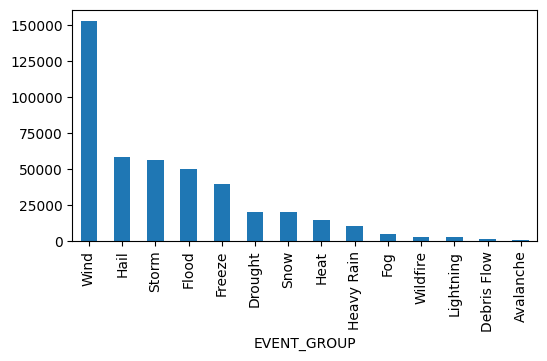

In [17]:
# aggregate each of these category leaving everthing else as it is:

df['EVENT_GROUP'] = df['EVENT_TYPE'].replace({
    'Thunderstorm Wind': 'Wind',
    'Hail': 'Hail',
    'Marine Hail': 'Hail',
    'Flood': 'Flood',
    'Flash Flood': 'Flood',
    'Coastal Flood': 'Flood',
    'Lakeshore Flood': 'Flood',
    'Winter Weather': 'Freeze',
    'Extreme Cold/Wind Chill': 'Freeze',
    'Frost/Freeze': 'Freeze',
    'Cold/Wind Chill': 'Freeze',
    'Freezing Fog': 'Freeze',
    'Heat': 'Heat',
    'Excessive Heat': 'Heat',
    'Heavy Snow': 'Snow',
    'Blizzard': 'Snow',
    'Lake-Effect Snow': 'Snow',
    'Sleet': 'Snow',
    'Winter Storm': 'Storm',
    'Marine Thunderstorm Wind': 'Storm',
    'Tornado': 'Storm',
    'Tropical Storm': 'Storm',
    'Dust Storm': 'Storm',
    'Funnel Cloud': 'Storm',
    'Ice Storm': 'Storm',
    'Waterspout': 'Storm',
    'Marine Tropical Storm': 'Storm',
    'Hurricane (Typhoon)': 'Storm',
    'Marine Hurricane/Typhoon': 'Storm',
    'High Wind':  'Wind',
    'Strong Wind':  'Wind',
    'Marine High Wind':  'Wind',
    'Marine Strong Wind':  'Wind',
    'Dense Fog':  'Fog',
    'Marine Dense Fog':  'Fog'
})

df['EVENT_GROUP'].value_counts().plot(kind='bar', figsize=(6, 3))

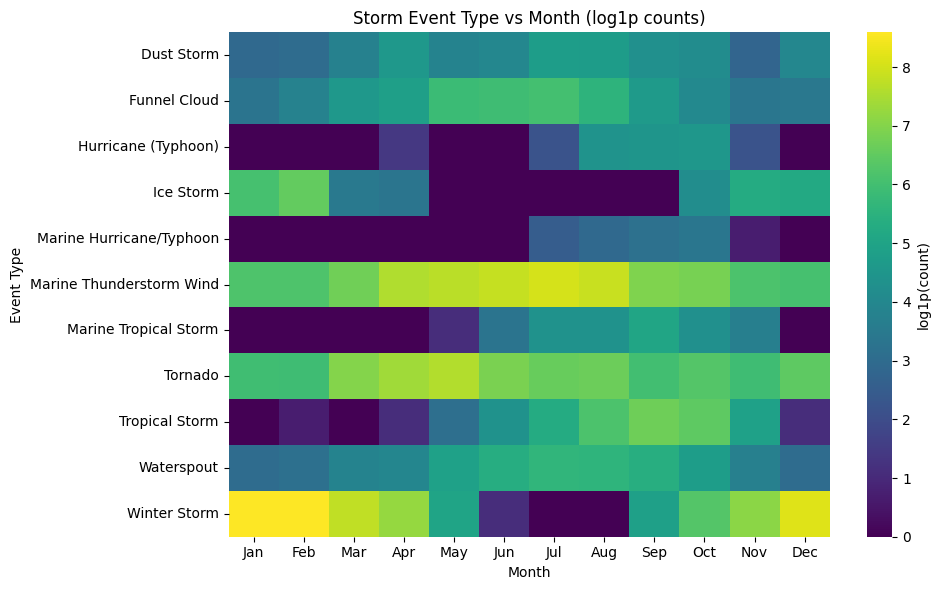

In [18]:
# plot the same correlation plot again for group and month, but only for storm related events
storm_events = df[df['EVENT_GROUP'] == 'Storm']
pivot_month_storm = pd.crosstab(storm_events['EVENT_TYPE'], storm_events['month_num']).reindex(columns=range(1,13), fill_value=0)
plt.figure(figsize=(10,6))
sns.heatmap(np.log1p(pivot_month_storm), cmap='viridis', cbar_kws={'label':'log1p(count)'})
plt.title('Storm Event Type vs Month (log1p counts)')
plt.xlabel('Month')
plt.ylabel('Event Type')
plt.xticks(np.arange(12)+0.5, [calendar.month_abbr[m] for m in range(1,13)], rotation=0)
plt.tight_layout()
plt.show()

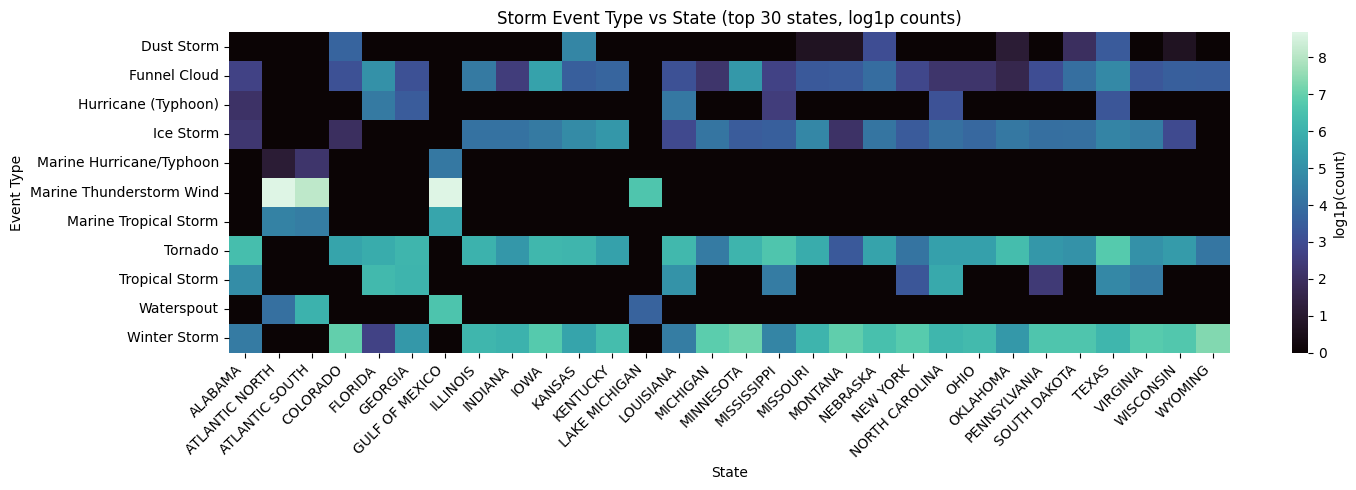

In [19]:
# plot the same correlation plot again for group and state, but only for storm related events, recomputing the top states only for storms
pivot_state_storm = pd.crosstab(storm_events['EVENT_TYPE'], storm_events['STATE'])
top_states_storm = storm_events['STATE'].value_counts().nlargest(30).index
pivot_state_storm = pivot_state_storm.loc[:, pivot_state_storm.columns.isin(top_states_storm)]
plt.figure(figsize=(15,5))
sns.heatmap(np.log1p(pivot_state_storm), cmap='mako', cbar_kws={'label':'log1p(count)'})
plt.title('Storm Event Type vs State (top 30 states, log1p counts)')
plt.xlabel('State')
plt.ylabel('Event Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### State

In [20]:
df['STATE'].value_counts()

STATE
TEXAS             28875
VIRGINIA          15942
KANSAS            15562
CALIFORNIA        14866
SOUTH DAKOTA      14718
                  ...  
LAKE ONTARIO         87
E PACIFIC            54
VIRGIN ISLANDS       31
ST LAWRENCE R        14
HAWAII WATERS         8
Name: count, Length: 67, dtype: int64

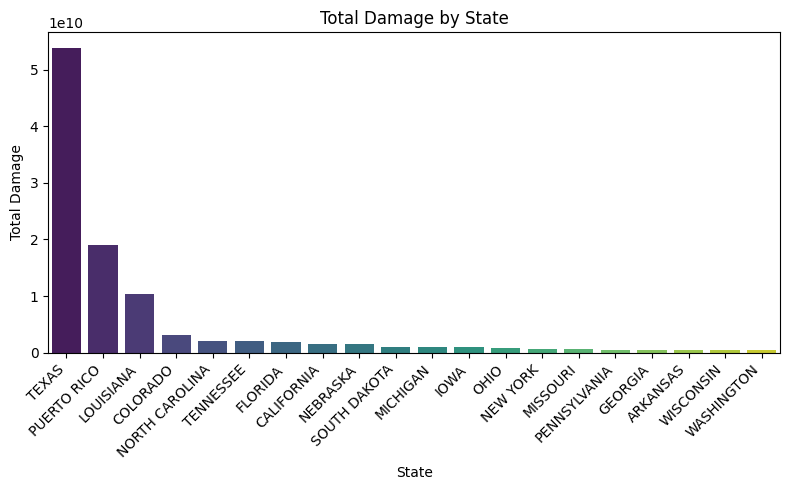

In [21]:
# plot hist of total damages per state for 20 most affected states
state_damage = df.groupby('STATE')['damage_total'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(8,5))  
sns.barplot(x=state_damage.index, y=state_damage.values, hue=state_damage.index, palette='viridis', legend=False)
plt.xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Damage')
plt.title('Total Damage by State')
plt.tight_layout()
plt.show()


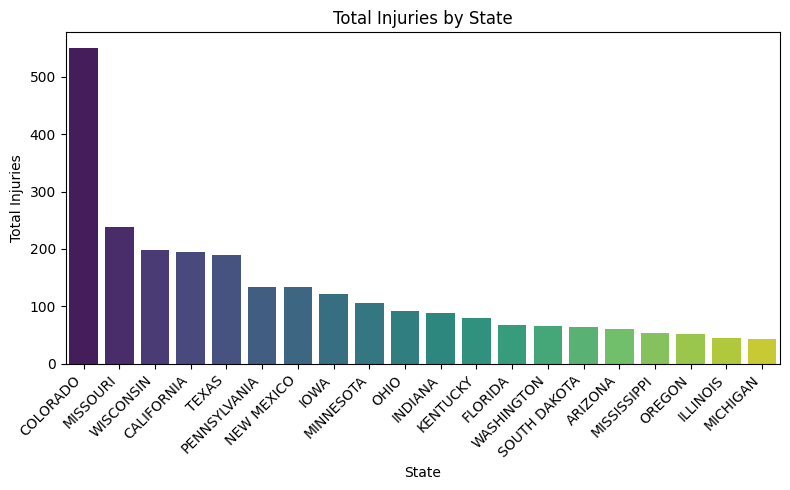

In [22]:
# plot hist of total injuries per state for 20 most affected states
state_injuries = df.groupby('STATE')['INJURIES_INDIRECT'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(8,5))  
sns.barplot(x=state_injuries.index, y=state_injuries.values, hue=state_injuries.index, palette='viridis', legend=False)
plt.xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Injuries')
plt.title('Total Injuries by State')
plt.tight_layout()
plt.show()


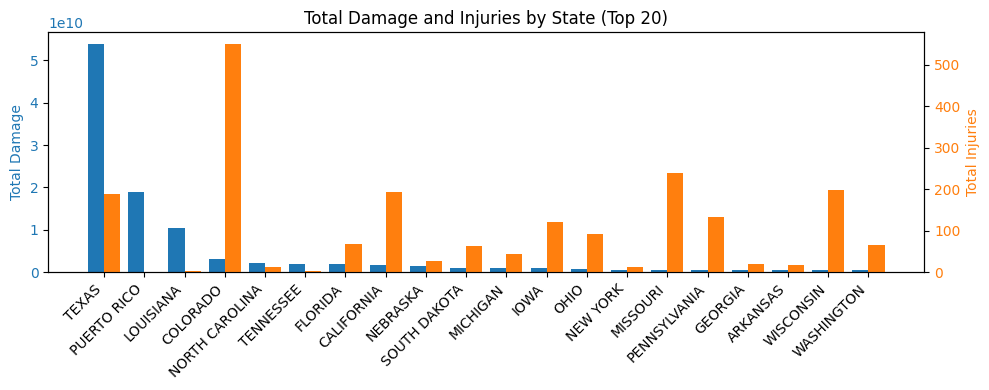

In [23]:
# Get top 20 states by damage
state_damage = df.groupby('STATE')['damage_total'].sum().sort_values(ascending=False).head(20)
state_injuries = df.groupby('STATE')['INJURIES_INDIRECT'].sum().reindex(state_damage.index)

fig, ax1 = plt.subplots(figsize=(10,4))

states = state_damage.index
bar_width = 0.4
x = np.arange(len(states))

# Damage bars (left y-axis)
ax1.bar(x - bar_width/2, state_damage.values, bar_width, label='Total Damage', color='tab:blue')
ax1.set_ylabel('Total Damage', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(x)
ax1.set_xticklabels(states, rotation=45, ha='right')

# Injuries bars (right y-axis)
ax2 = ax1.twinx()
ax2.bar(x + bar_width/2, state_injuries.values, bar_width, label='Total Injuries', color='tab:orange')
ax2.set_ylabel('Total Injuries', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Total Damage and Injuries by State (Top 20)')
fig.tight_layout()
plt.show()

### Time

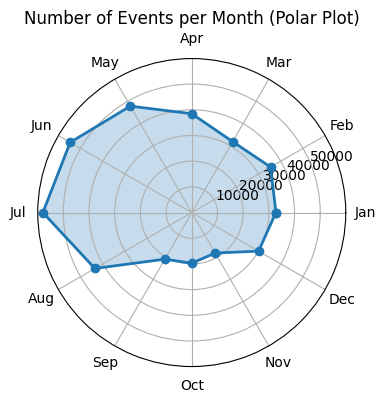

In [24]:
# Prepare data
months = [calendar.month_abbr[m] for m in range(1, 13)]
event_month_counts = df['month_name'].value_counts().reindex([calendar.month_abbr[m] for m in range(1,13)], fill_value=0)
values = event_month_counts.values
angles = np.linspace(0, 2 * np.pi, len(months), endpoint=False).tolist()
values = np.concatenate((values, [values[0]]))  # close the circle
angles += [angles[0]]

# Plot
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw={'polar': True})
ax.plot(angles, values, 'o-', linewidth=2)
ax.fill(angles, values, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(months)
ax.set_title('Number of Events per Month (Polar Plot)')
plt.show()

### Effects

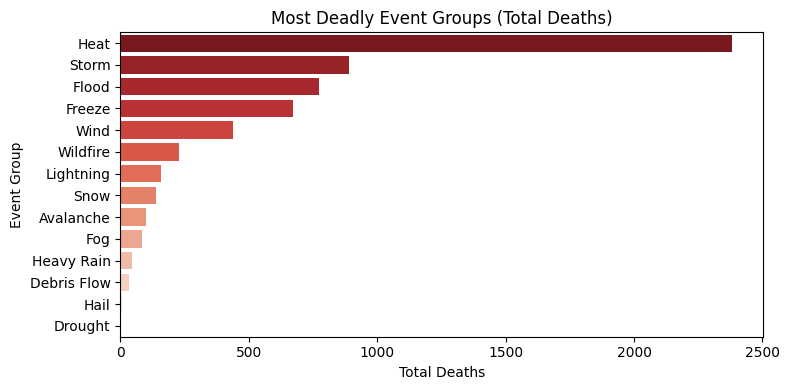

In [25]:
# Calculate total deaths per event group
df['deaths_total'] = df['DEATHS_DIRECT'].fillna(0) + df['DEATHS_INDIRECT'].fillna(0)
deadly_by_group = df.groupby('EVENT_GROUP')['deaths_total'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(x=deadly_by_group.values, y=deadly_by_group.index, hue=deadly_by_group.index, legend=False, palette='Reds_r')
plt.xlabel('Total Deaths')
plt.ylabel('Event Group')
plt.title('Most Deadly Event Groups (Total Deaths)')
plt.tight_layout()
plt.show()

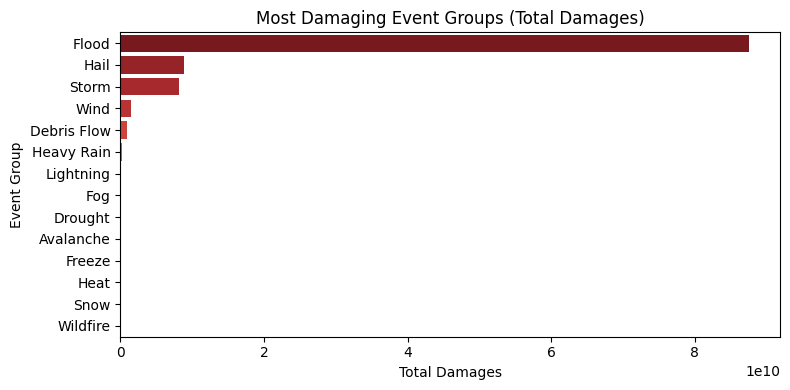

In [26]:
# Calculate total deaths per event group
df['deaths_damages'] = df_numeric['DAMAGE_PROPERTY'].fillna(0) + df_numeric['DAMAGE_CROPS'].fillna(0)
deadly_by_group = df.groupby('EVENT_GROUP')['deaths_damages'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(x=deadly_by_group.values, y=deadly_by_group.index, hue=deadly_by_group.index, legend=False, palette='Reds_r')
plt.xlabel('Total Damages')
plt.ylabel('Event Group')
plt.title('Most Damaging Event Groups (Total Damages)')
plt.tight_layout()
plt.show()

### Tor F Scale

In [35]:
df['TOR_F_SCALE'].value_counts()

TOR_F_SCALE
EF0    4332
EF1    3646
EF2     884
EFU     825
EF3     181
EF4      31
Name: count, dtype: int64

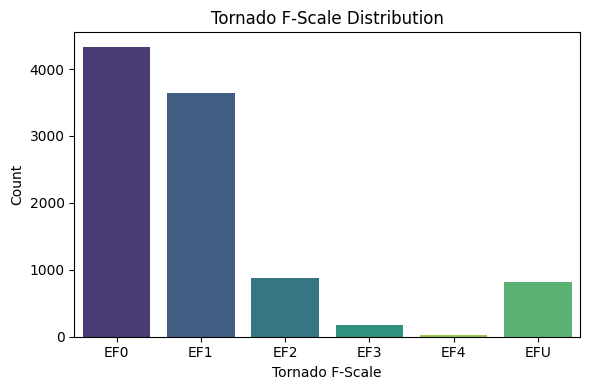

In [ ]:
# plot tornado F-scale distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='TOR_F_SCALE', order=sorted(df['TOR_F_SCALE'].dropna().unique()), hue='TOR_F_SCALE', legend=False, palette='viridis')
plt.xlabel('Tornado F-Scale')
plt.ylabel('Count')
plt.title('Tornado F-Scale Distribution')
plt.tight_layout()
plt.show()

### Magnitude

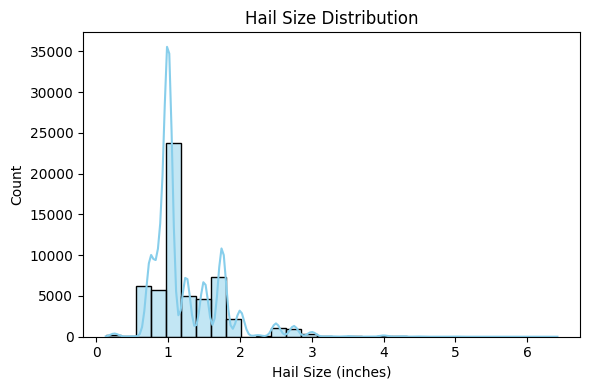

In [ ]:
df_hail = df[df['EVENT_GROUP'] == 'Hail']
plt.figure(figsize=(6,4))
sns.histplot(df_hail['MAGNITUDE'], bins=30, kde=True, color='skyblue')
plt.xlabel('Hail Size (inches)')
plt.ylabel('Count')
plt.title('Hail Magnitude Distribution')
plt.tight_layout()
plt.show()

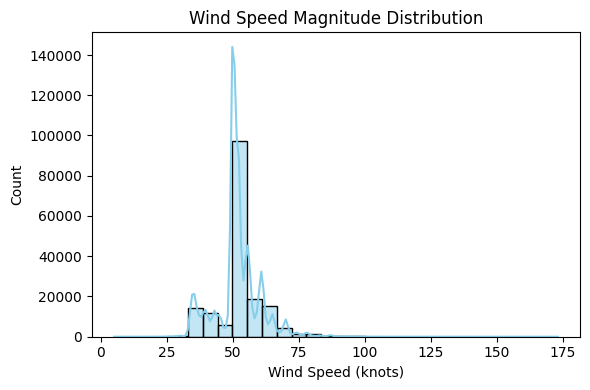

In [46]:
df_wind = df[df['EVENT_GROUP'] != 'Hail']
plt.figure(figsize=(6,4))
sns.histplot(df_wind['MAGNITUDE'], bins=30, kde=True, color='skyblue')
plt.xlabel('Wind Speed (knots)')
plt.ylabel('Count')
plt.title('Wind Speed Magnitude Distribution')
plt.tight_layout()
plt.show()